# Neural Models Lab

This notebook contains the code parts of the lab.

## Task 1 — XOR Data Visualization

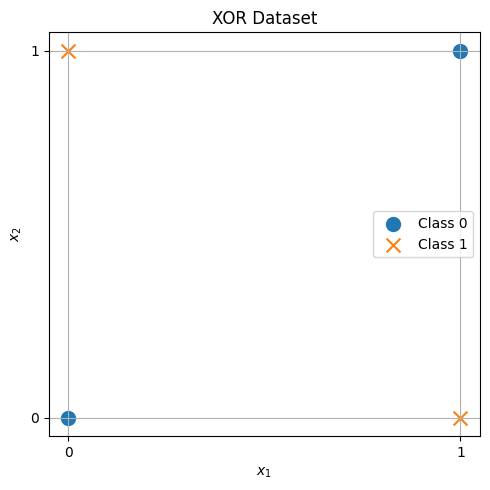

In [1]:
import matplotlib.pyplot as plt

# XOR dataset
X = [(0, 0), (0, 1), (1, 0), (1, 1)]
y = [0, 1, 1, 0]

class_0 = [X[i] for i in range(len(X)) if y[i] == 0]
class_1 = [X[i] for i in range(len(X)) if y[i] == 1]

plt.figure(figsize=(5, 5))

plt.scatter(
    [p[0] for p in class_0],
    [p[1] for p in class_0],
    marker='o',
    s=100,
    label='Class 0'
)

plt.scatter(
    [p[0] for p in class_1],
    [p[1] for p in class_1],
    marker='x',
    s=100,
    label='Class 1'
)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('XOR Dataset')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("xor_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## Task 3 — First PyTorch Implementation

In [2]:
import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(42)

# XOR dataset
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

# 2 -> 2 -> 1 network
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        x = torch.sigmoid(self.hidden(x))
        x = self.output(x)
        return x

# Model, loss, and optimizer
model = XORNet()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# Initial loss
with torch.no_grad():
    initial_logits = model(X)
    initial_loss = criterion(initial_logits, y)

print(f"Initial loss: {initial_loss.item():.6f}")

# Full-batch training
num_steps = 3000

for step in range(num_steps):
    optimizer.zero_grad()

    # Forward pass
    logits = model(X)

    # Scalar loss
    loss = criterion(logits, y)

    # Backward pass
    loss.backward()

    # Parameter update
    optimizer.step()

# Final forward pass
final_logits = model(X)
final_loss = criterion(final_logits, y)

# Convert logits to probabilities
probabilities = torch.sigmoid(final_logits)

# Threshold probabilities at 0.5
predictions = (probabilities >= 0.5).float()

print(f"\nFinal loss: {final_loss.item():.6f}")

print("\nPredicted probabilities:")
for i, p in enumerate(probabilities):
    print(f"Input {X[i].tolist()} -> {p.item():.6f}")

print("\nThresholded predictions:")
for i, pred in enumerate(predictions):
    print(f"Input {X[i].tolist()} -> {int(pred.item())}")

# Expose a gradient tensor after backward()
print("\nFirst-layer weight gradient:")
print(model.hidden.weight.grad)


Initial loss: 0.748230

Final loss: 0.000340

Predicted probabilities:
Input [0.0, 0.0] -> 0.000308
Input [0.0, 1.0] -> 0.999694
Input [1.0, 0.0] -> 0.999554
Input [1.0, 1.0] -> 0.000299

Thresholded predictions:
Input [0.0, 0.0] -> 0
Input [0.0, 1.0] -> 1
Input [1.0, 0.0] -> 1
Input [1.0, 1.0] -> 0

First-layer weight gradient:
tensor([[ 5.1401e-06, -5.7570e-06],
        [ 2.7487e-06, -3.9397e-06]])


##Task4:

In [5]:
import torch
import torch.nn as nn

# XOR dataset
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])


class XORNet(nn.Module):
    def __init__(self, activation="sigmoid"):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)
        self.activation = activation

    def forward(self, x):
        z = self.hidden(x)

        if self.activation == "sigmoid":
            h = torch.sigmoid(z)
        elif self.activation == "tanh":
            h = torch.tanh(z)
        elif self.activation == "relu":
            h = torch.relu(z)

        return self.output(h)


# ============================================================
# Part A + Part B: Basic learning and backpropagation check
# ============================================================

torch.manual_seed(42)

model = XORNet("sigmoid")
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# Initial loss
with torch.no_grad():
    initial_loss = criterion(model(X), y).item()

print("Initial loss:", initial_loss)

# Training
num_steps = 3000

for step in range(num_steps):
    optimizer.zero_grad()

    logits = model(X)
    loss = criterion(logits, y)

    loss.backward()

    # Save gradient from an early training step
    if step == 0:
        early_gradient = model.hidden.weight.grad.detach().clone()

    optimizer.step()

# Final results
with torch.no_grad():
    final_logits = model(X)
    final_loss = criterion(final_logits, y).item()
    probabilities = torch.sigmoid(final_logits)
    predictions = (probabilities >= 0.5).float()

print("\nFinal loss:", final_loss)

print("\nFinal probabilities:")
for i in range(4):
    print(
        f"{X[i].tolist()} -> "
        f"{probabilities[i].item():.6f}"
    )

print("\nThresholded predictions:")
for i in range(4):
    print(
        f"{X[i].tolist()} -> "
        f"{int(predictions[i].item())}"
    )

print("\nFirst-layer gradient after backward():")
print(early_gradient)

print("\nEarly gradient norm:")
print(early_gradient.norm().item())


# ============================================================
# Part C: Symmetry experiment
# ============================================================

torch.manual_seed(42)

zero_model = XORNet("sigmoid")

# Zero-initialize all trainable parameters
with torch.no_grad():
    for parameter in zero_model.parameters():
        parameter.zero_()

zero_optimizer = torch.optim.Adam(
    zero_model.parameters(),
    lr=0.05
)

print("\n--- Symmetry Experiment ---")

for step in range(6):
    print(f"\nStep {step}:")
    print("Hidden weight matrix:")
    print(zero_model.hidden.weight.detach())

    print("Hidden bias:")
    print(zero_model.hidden.bias.detach())

    zero_optimizer.zero_grad()

    logits = zero_model(X)
    loss = criterion(logits, y)

    loss.backward()
    zero_optimizer.step()


# ============================================================
# Part D: Activation experiment
# ============================================================

def run_activation_experiment(activation, seed=42):
    torch.manual_seed(seed)

    model = XORNet(activation)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

    # Initial loss
    with torch.no_grad():
        initial_loss = criterion(model(X), y).item()

    # First backward pass for early gradient
    optimizer.zero_grad()

    logits = model(X)
    loss = criterion(logits, y)

    loss.backward()

    early_gradient_norm = model.hidden.weight.grad.norm().item()

    optimizer.step()

    # Remaining training
    for _ in range(2999):
        optimizer.zero_grad()

        logits = model(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

    # Final results
    with torch.no_grad():
        logits = model(X)
        final_loss = criterion(logits, y).item()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct = int((predictions == y).all())

    return (
        initial_loss,
        final_loss,
        correct,
        early_gradient_norm,
        probabilities,
        predictions
    )


print("\n--- Activation Experiment ---")

results = {}

for activation in ["sigmoid", "tanh", "relu"]:
    results[activation] = run_activation_experiment(activation)

    initial_loss, final_loss, correct, gradient_norm, probabilities, predictions = results[activation]

    print(f"\nActivation: {activation}")
    print(f"Initial loss: {initial_loss:.6f}")
    print(f"Final loss: {final_loss:.6f}")
    print(f"4/4 correct: {bool(correct)}")
    print(f"Early ||gradient||: {gradient_norm:.6f}")

    print("Probabilities:")
    print(probabilities.squeeze())

    print("Predictions:")
    print(predictions.squeeze())

Initial loss: 0.7482295036315918

Final loss: 0.00033990677911788225

Final probabilities:
[0.0, 0.0] -> 0.000308
[0.0, 1.0] -> 0.999694
[1.0, 0.0] -> 0.999554
[1.0, 1.0] -> 0.000299

Thresholded predictions:
[0.0, 0.0] -> 0
[0.0, 1.0] -> 1
[1.0, 0.0] -> 1
[1.0, 1.0] -> 0

First-layer gradient after backward():
tensor([[-0.0040, -0.0044],
        [ 0.0064,  0.0081]])

Early gradient norm:
0.0118937436491251

--- Symmetry Experiment ---

Step 0:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hidden bias:
tensor([0., 0.])

Step 1:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hidden bias:
tensor([0., 0.])

Step 2:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hidden bias:
tensor([0., 0.])

Step 3:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hidden bias:
tensor([0., 0.])

Step 4:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hidden bias:
tensor([0., 0.])

Step 5:
Hidden weight matrix:
tensor([[0., 0.],
        [0., 0.]])
Hi

##Task5:


In [4]:
import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(42)

# Same sensor inputs
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

# Three classes:
# 0 -> both sensors inactive
# 1 -> sensors disagree
# 2 -> both sensors active
y = torch.tensor([0, 1, 1, 2])


# 2 -> 2 -> 3 network
class ThreeClassNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 3)

    def forward(self, x):
        hidden = torch.sigmoid(self.hidden(x))
        logits = self.output(hidden)
        return logits


model = ThreeClassNet()

# Multiclass cross-entropy
criterion = nn.CrossEntropyLoss()

# Gradient-based optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# Full-batch training
num_steps = 3000

for step in range(num_steps):
    optimizer.zero_grad()

    logits = model(X)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()


# Final logits and probabilities
with torch.no_grad():
    logits = model(X)
    probabilities = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probabilities, dim=1)

print("Final loss:", loss.item())

print("\nPredicted class probabilities:")
for i in range(4):
    print(
        f"Input {X[i].tolist()} -> "
        f"{probabilities[i].tolist()}"
    )

print("\nPredicted classes:")
for i in range(4):
    print(
        f"Input {X[i].tolist()} -> "
        f"Class {predictions[i].item()}"
    )


# Verify probabilities sum to 1 for one example
example_probabilities = probabilities[0]

print("\nProbability vector for [0, 0]:")
print(example_probabilities)

print("\nSum of probabilities:")
print(example_probabilities.sum().item())


# Optional numerical stability diagnostic
shifted_logits = logits + 100
shifted_probabilities = torch.softmax(shifted_logits, dim=1)

print("\nProbabilities after adding 100 to all logits:")
print(shifted_probabilities)

print("\nMaximum difference:")
print(
    torch.max(
        torch.abs(probabilities - shifted_probabilities)
    ).item()
)

Final loss: 0.00024634477449581027

Predicted class probabilities:
Input [0.0, 0.0] -> [0.9997212290763855, 0.00027877948014065623, 2.9389695122006287e-09]
Input [0.0, 1.0] -> [0.00011189588258275762, 0.9997898936271667, 9.826228051679209e-05]
Input [1.0, 0.0] -> [0.00010969330469379202, 0.999790608882904, 9.971699910238385e-05]
Input [1.0, 1.0] -> [8.488926894756332e-09, 0.00028611443121917546, 0.9997138381004333]

Predicted classes:
Input [0.0, 0.0] -> Class 0
Input [0.0, 1.0] -> Class 1
Input [1.0, 0.0] -> Class 1
Input [1.0, 1.0] -> Class 2

Probability vector for [0, 0]:
tensor([9.9972e-01, 2.7878e-04, 2.9390e-09])

Sum of probabilities:
1.0

Probabilities after adding 100 to all logits:
tensor([[9.9972e-01, 2.7878e-04, 2.9390e-09],
        [1.1190e-04, 9.9979e-01, 9.8262e-05],
        [1.0969e-04, 9.9979e-01, 9.9717e-05],
        [8.4890e-09, 2.8612e-04, 9.9971e-01]])

Maximum difference:
1.076841726899147e-09
